Figure S3: pcQTL mapping null with shuffled genotypes. For each pcGene and eGene phenotype for clusters in cultured fibroblast tissue, the genotypes at each variant position were shuffled. SuSiE was then run with the shuffled genotype and with the real genotypes to map pcQTLs and eQTLs. pcGenes were not significantly more likely to map false positive pcQTLs with the shuffled genotype than eGenes mapping false positive eQTLs with the shuffled genotype and eGenes (Fisher exact p-value=1.0).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy.stats import fisher_exact

from tqdm.auto import tqdm 
tqdm.pandas()

prefix = '/home/klawren/oak/pcqtls'
import yaml
config_path= f'{prefix}/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append('/home/klawren/oak/pcqtls/workflow/scripts')
from utils import *
from annotate_clusters import * 


%config InlineBackend.figure_formats = ['png']
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

In [ ]:
from tensorqtl import susie, genotypeio, read_phenotype_bed
from get_pcs import get_pc_bed

In [ ]:

# PLINK reader for genotypes
plink_prefix_path = '/home/klawren/oak/pcqtls/data/processed/genotypes/GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.MAF01'

pgr = genotypeio.PlinkReader(plink_prefix_path)
genotype_df = pgr.load_genotypes()

variant_df = pgr.bim.set_index('snp')[['chrom', 'pos']]

Mapping files: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:22<00:00,  7.44s/it]


In [ ]:
pc_phenotype_df, pc_phenotype_pos_df = read_phenotype_bed('{}/{}/{}.pcs.bed'.format(prefix, config['pc_output_dir'], my_tissue_id))
phenotype_df, phenotype_pos_df = read_phenotype_bed('{}/{}/{}.v8.normalized_residualized_expression.cluster_genes.bed'.format(prefix, config['filtered_expression_output_dir'], my_tissue_id))
covariates_df = pd.read_csv('{}/{}/{}.v8.covariates.txt'.format(prefix, config['covariates_dir'], my_tissue_id), sep='\t', index_col=0).T
tissue_cluster_df = load_cluster(config, my_tissue_id)

In [ ]:
# create shuffled expression and pcs
reordered = []
for idx, row in phenotype_df.iterrows():
    reordered.append(row.sample(frac=1).set_axis(phenotype_df.columns))
shuffled_e_phenotype_df = pd.DataFrame(reordered)

# get shuffled expression to right format
shuff_e_expression_df = pd.merge(phenotype_pos_df, shuffled_e_phenotype_df, left_on='gene_id', right_index=True).reset_index()
shuff_e_expression_df.rename(columns={'chr':'#chr'}, inplace=True)

# get pcs from shuffled expression
shuff_pc_expression_df = get_pc_bed(tissue_cluster_df, shuff_e_expression_df, covariates_df)
shuff_pc_phenotype_df = shuff_pc_expression_df[shuff_pc_expression_df.columns[3:]].set_index('gene_id')

Dropped 0 rows due to inf


In [ ]:
# map e and pc qlts from shuffled expression 

shuff_e_susie_summary, shuff_e_susie_res = susie.map(genotype_df, variant_df, 
                        shuffled_e_phenotype_df, 
                        phenotype_pos_df,
                        covariates_df, 
                        summary_only=False)

shuff_e_susie_summary.to_csv('/home/klawren/oak/pcqtls/temp/shuff_e_susie_summary.txt', sep='\t')

SuSiE fine-mapping
  * 483 samples
  * 1872 phenotypes
  * 68 covariates
  * 10770860 variants
  * cis-window: ±1,000,000
  * checking phenotypes: 1872/1872
  * fine-mapping
    processing phenotype 1872/1872
  Time elapsed: 23.10 min
done.


In [ ]:
shuff_pc_susie_summary, shuff_pc_susie_res = susie.map(genotype_df, variant_df, 
                        shuff_pc_phenotype_df, 
                        pc_phenotype_pos_df,
                        covariates_df, 
                        summary_only=False)
shuff_pc_susie_summary.to_csv('/home/klawren/oak/pcqtls/temp/shuff_pc_susie_summary.txt', sep='\t')

SuSiE fine-mapping
  * 483 samples
  * 1872 phenotypes
  * 68 covariates
  * 10770860 variants
  * cis-window: ±1,000,000
  * checking phenotypes: 1872/1872
  * fine-mapping
    processing phenotype 1872/1872
  Time elapsed: 22.75 min
done.


In [ ]:
orig_e_susie_summary = load_e_susie(config, my_tissue_id)
orig_pc_susie_summary = load_pc_susie(config, my_tissue_id)

In [ ]:
def get_frac_with_signal(susie_summary, total_signals = len(phenotype_df)):
    return susie_summary['phenotype_id'].nunique()/total_signals

def get_num_cs(susie_summary):
    return len(susie_summary.groupby(['phenotype_id', 'cs_id']).nunique())

cs_counts = pd.DataFrame({'shuffled':['shuffled', 'shuffled', 'original', 'original'], 
              'type':['eqtl', 'pcqtl', 'eqtl', 'pcqtl'], 
              'num_cs':[get_num_cs(shuff_e_susie_summary), get_num_cs(shuff_pc_susie_summary), get_num_cs(orig_e_susie_summary), get_num_cs(orig_pc_susie_summary)],
              'frac_signal':[get_frac_with_signal(shuff_e_susie_summary), get_frac_with_signal(shuff_pc_susie_summary), get_frac_with_signal(orig_e_susie_summary), get_frac_with_signal(orig_pc_susie_summary)]})


/local/scratch/klawren/slrmtmp.49586076/ipykernel_18230/631666421.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Shuffled genotypes', 'Original genotypes'])


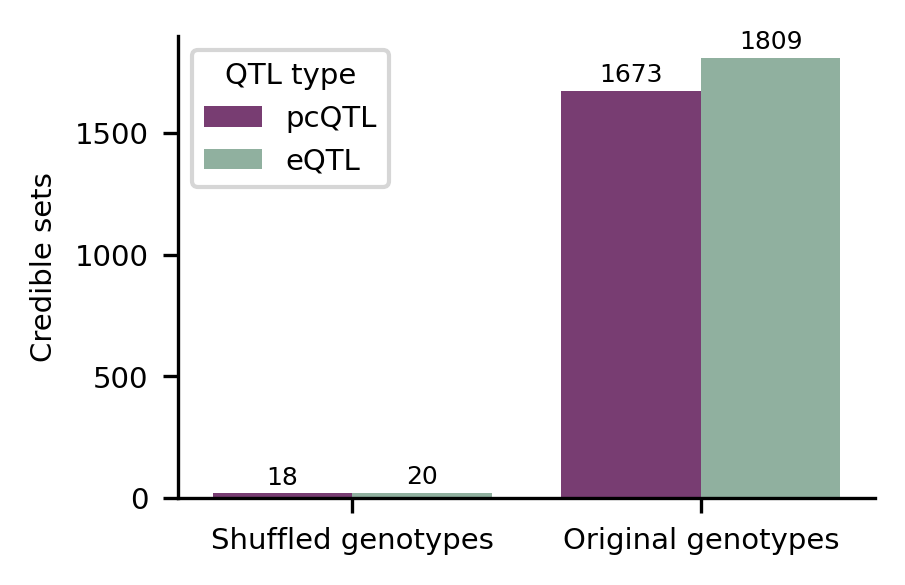

In [14]:
fig, ax = plt.subplots(figsize=(3,2), dpi=300)

barplot = sns.barplot(cs_counts, ax=ax, y='num_cs', x='shuffled', hue='type', hue_order=['pcqtl','eqtl'], palette=[qtl_palette['pcQTL only'], qtl_palette['eQTL only']], alpha=.8)
ax.set_ylabel('Credible sets')
ax.set_xlabel('')
ax.spines[['top', 'right']].set_visible(False)
ax.bar_label(ax.containers[0], fontsize=6, padding=1)
ax.bar_label(ax.containers[1], fontsize=6, padding=1)
# Set legend labels manually, preserving correct colors
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['pcQTL', 'eQTL'], title="QTL type")
ax.set_xticklabels(['Shuffled genotypes', 'Original genotypes'])

plt.savefig("/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s3.pdf", transparent=True)
plt.show()

In [10]:
contingency = cs_counts.pivot(index='shuffled', columns='type', values='num_cs').loc[['original', 'shuffled'], ['eqtl', 'pcqtl']].values
oddsratio, pvalue = fisher_exact(contingency)
print(f"Fisher's exact test p-value for num_cs (original vs shuffled, eqtl vs pcqtl): {pvalue}")

Fisher's exact test p-value for num_cs (original vs shuffled, eqtl vs pcqtl): 1.0
